#Project 2: Heart Disease Diagnostic Analysis

##**Overview**

Cardiovascular diseases (CVDs) are the number one cause of death globally, taking an estimated 17.9 million lives each year. Heart failure is a chronic cardiovascular disease (CVD) that occurs when the heart muscle cannot pump blood efficiently enough to meet the body's needs. It is considered a functional, end-stage result of various heart conditions rather than a single disease. Identifying high-risk patients early is critical for medical intervention.

This project utilizes a clinical dataset, which consists of 918 observations with 12 variables, providing a mix of demographic data, symptoms and clinical measurements, to explore the physiological markers that contribute to heart disease and to develop a predictive framework for diagnosis.

### **Dataset Features**

| Feature |Meaning |
| --- | --- |
| **HeartDisease** | Target variable (output class [1: heart disease, 0: Normal]) |
| **age** | age of the patient [years] |
| **Sex** | sex of the patient [M: Male, F: Female] |
| **ChestPainType** | chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic] |
| **RestingBP** | resting blood pressure [mm Hg] |
| **Cholesterol** | serum cholesterol [mm/dl] |
| **FastingBS** | fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise] |
| **RestingECG** | resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria] |
| **MaxHR** | maximum heart rate achieved [Numeric value between 60 and 202] |
| **ExerciseAngina** | exercise-induced angina [Y: Yes, N: No] |
| **Oldpeak** | oldpeak = ST [Numeric value measured in depression] |
| **ST_Slope** | the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping] |

###Initial Research Questions
The four questions below are the questions that I formulated and made me curious about this specific dataset. However, there will be expected additional questions during exploration and analysis.
1. Does heart failure only affect the elderly people more than young people in this dataset?
2. In this dataset, which gender (male or female) has a higher frequency of heart disease?
3. Does having a symptom such as chest pain guarantee a person to be having a heart disease?
4. Is diabetes (FastingBS 'Blood Sugar') have increase a patients risk of having a heart disease?

##1. **LOAD THE DATASET**

In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
orig_df = pd.read_csv('/content/drive/MyDrive/heart.csv')

# Look at the first 5 rows to ensure it loaded correctly
orig_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


##2. **DATA AUDITING**

In [224]:
# Check the dimensions (Rows, Columns)
print(f"Dataset Shape: {orig_df.shape}")

# Check data types and look for missing values
orig_df.info()

Dataset Shape: (918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


* There are 918 rows and 12 columns in the entire dataset.
* The columns are in its respective data types and there is no missing number of counts in each column.

In [225]:
# Count missing values per column
missing_values = orig_df.isnull().sum()
print(missing_values)

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


* There is no missing values in each column.

In [226]:
# Check for duplicate rows
duplicate_count = orig_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [227]:
# Get a statistical summary
orig_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


* It is impossible for RestingBP and Cholesterol to be zero. This might be a placeholder or a data entry error.
* This makes the mean of RestingBP higher than normal.
* This is because in the real world it is not medically possible for a living person.

##3. **DATA CLEANING**

####Imputation
Filling in missing or incorrect data instead of deleting it.

In [228]:
'''
The median was used to fill in the missing or incorrect values
because the data had outliers that the mean would have been sensitive to.
The Median is robust and ensures that our clean data points represent a typical
patient without being distorted by extreme cases in the study.
'''
# Calculate the 'true' median (ignoring the 0s)
chol_median = orig_df[orig_df['Cholesterol'] != 0]['Cholesterol'].median()
rest_BP_median = orig_df[orig_df['RestingBP'] != 0]['RestingBP'].median()
# Replace the 0s with that median
orig_df['Cholesterol'] = orig_df['Cholesterol'].replace(0, chol_median)
orig_df['RestingBP'] = orig_df['RestingBP'].replace(0, rest_BP_median)

print(orig_df.describe())

              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.538126   243.204793    0.233115  136.809368   
std      9.432617   17.990127    53.401297    0.423046   25.460334   
min     28.000000   80.000000    85.000000    0.000000   60.000000   
25%     47.000000  120.000000   214.000000    0.000000  120.000000   
50%     54.000000  130.000000   237.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.887364      0.553377  
std      1.066570      0.497414  
min     -2.600000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      6.200000      1.000000  


* The RestingBP minimum was fixed to 80 and Cholesterol is 85. These are more realistic for a living person.
* The average for Cholesterol has changed from 198 to 243.

In [229]:
# Check unique values in categorical columns
print(orig_df['Sex'].unique())
print(orig_df['ChestPainType'].unique())
print(orig_df['RestingECG'].unique())
print(orig_df['ExerciseAngina'].unique())
print(orig_df['ST_Slope'].unique())

['M' 'F']
['ATA' 'NAP' 'ASY' 'TA']
['Normal' 'ST' 'LVH']
['N' 'Y']
['Up' 'Flat' 'Down']


* The categorical data does not seem to have duplicates. For example, 'M' and 'Male'.

##DATA VISUALIZATION OF THE ENTIRE DATASET

(np.float64(-1.1531196523259752),
 np.float64(1.1025140644426024),
 np.float64(-1.1905706343718165),
 np.float64(1.1043067390027177))

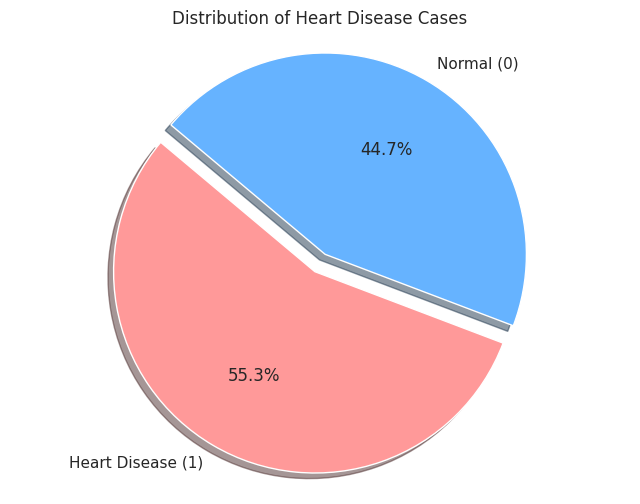

In [230]:
#VISUALIZATION OF THE TARGET VARIABLE FOR THE DATASET WITH A PIE CHART

#The Class Balance; Class 1(Heart Disease) and Class 0(Normal)
#Count how many patients have heart disease (1) and how many are normal (0)
# value_counts() is a great way to get the totals for each category
heart_disease_counts = orig_df['HeartDisease'].value_counts()

#Set up the visual details for the chart
labels = ['Heart Disease (1)', 'Normal (0)']
colors = ['#ff9999','#66b3ff'] #These are the codes for the colours,soft red for disease and soft blue for normal
explode = (0.1, 0)  # This "pops out" the first slice (Heart Disease) to make it stand out

#Create the pie chart
plt.figure(figsize=(8, 6)) # Set the size of the chart
plt.pie(
    heart_disease_counts,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%', # This line adds the percentage labels inside the slices
    shadow=True,       # Adds a 3D shadow effect
    startangle=140     # Rotates the start of the chart for a better look
)

#Add a title and show the plot
plt.title('Distribution of Heart Disease Cases')
plt.axis('equal')  # This ensures the pie is drawn as a perfect circle

#Save the image
##plt.savefig('heart_disease_distribution.png')

**Interpretation**: The pie chart showed 55.3% of the patients had a heart disease and 44.7% of patients were normal. The dataset is relatively balanced as there are plenty of examples for both healthy and sick patients.The difference between the two classes is not that much.

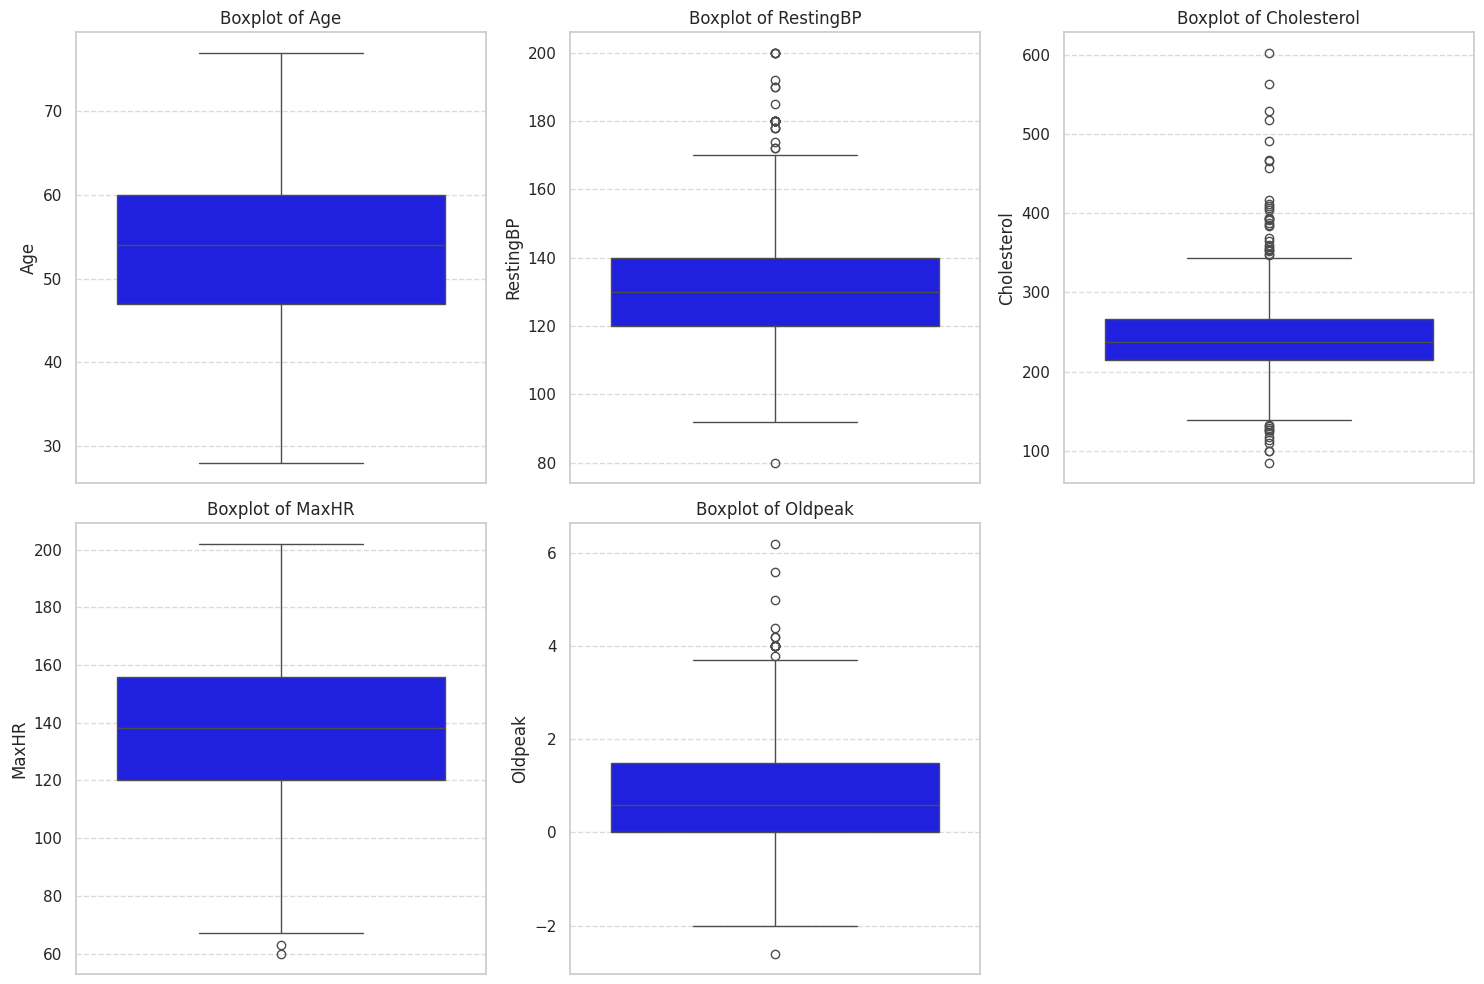

In [231]:
#VISUALIZATION FOR OUTLIERS WITH BOXPLOT

#Define the numerical columns to check
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

#Set up a grid of plots
plt.figure(figsize=(15, 10))

# 4. Loop through the columns and create a boxplot for each
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=orig_df[col], color='#0000FF')
    plt.title(f'Boxplot of {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Adjust layout and save
plt.tight_layout()

plt.show()


* Age had no outliers. RestingBP had many dots(outliers) above the whiskers, which showed patients with very high blood pressure and one dot below the whiskers,which showed very low blood pressure. Cholesterol had many dots(outliers) above the whiskers, which showed patients with very high cholesterol and a few dots (outliers) below the whiskers, which showed patients with very low cholesterol. Oldpeak had many dots (outliers) above the whiskers, which showed patients with a very high ST depression (how well your heart works under stress) and one dot (outlier) below the whiskers to show patients with a low ST depression. MaxHR had a few dots (outliers) below the whiskers, which showed patients with very low exercise heart rates.

##4. **SPLITTING THE DATASET**
We split before we do Data Preprocessing(encoding and scaling) to avoid data leakage.

* Data Leakage is when information from the test set (which is supposed to be unseen) accidentally leaks into your training set during preprocessing stage.
* This happens because when you encode or scale the entire dataset at once, the statistics of the test set(the average income or the frequency of 'Engineers') influence the values in the training set.
* This gives the model a sneak peak at the answers, leading to artificially high accuracy that fails in the real world.

In [232]:
from sklearn.model_selection import train_test_split

#Separate Features (X) and Target (y)
#X is the "Input": Everything the model uses to learn (Age, RestingBP, etc.)
#y is the "Answer Key": What is wanted to predict (HeartDisease)
X = orig_df.drop('HeartDisease', axis=1)
y = orig_df['HeartDisease']

#Perform the Split
#test_size=0.2 means 80% of data is for Training and 20% for Testing
#random_state=42 is like a "seed" that ensures you get the same split every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Check the results
print(f"Total rows in dataset: {len(orig_df)}")
print(f"Training set: {len(X_train)} rows")
print(f"Testing set: {len(X_test)} rows")

Total rows in dataset: 918
Training set: 734 rows
Testing set: 184 rows


* The dataset has been split into 80% Training data and 20% Test data. The training set has 734 rows, while test set has 184 rows.

##5. **Data Preprocessing**
###5.1 Encoding

Encoding is the process of converting data that is usually in text format into a format  that a computer can understand, which is numerical. There are different types of encoding used in data science but in this particular project we will be using Binary Mapping, One-Hot Encoding and Target Encoding.

*   Binary Mapping: It is used when the variable/feature only has two options. For instance "yes/no", "male/female" etc.

*   One-Hot Encoding: It is used when there is no order between catergories. It creates and uses new dummy columns for the each categories of the specific column with more than two values. If the category is present in that specific dummy column then it gets 1 otherwise it gets 0.Best for low cardinality(2-5 categories).

In [233]:
#Binary Mapping for Sex and ExerciseAngina
#Create a dictionary for the mapping
sex_mapping = {'M': 1, 'F': 0}
angina_mapping = {'Y': 1, 'N': 0}

#Apply the mapping to the Training Set
X_train['Sex'] = X_train['Sex'].map(sex_mapping)
X_train['ExerciseAngina'] = X_train['ExerciseAngina'].map(angina_mapping)

#Apply the EXACT SAME mapping to the Testing Set
X_test['Sex'] = X_test['Sex'].map(sex_mapping)
X_test['ExerciseAngina'] = X_test['ExerciseAngina'].map(angina_mapping)

# Check the first few rows
print(print("\n--- Train Dataset ---"))
print(X_train[['Sex', 'ExerciseAngina']].head())
print("\n--- Test Dataset ---")
print(X_test[['Sex', 'ExerciseAngina']].head())


--- Train Dataset ---
None
     Sex  ExerciseAngina
795    1               0
25     1               0
84     1               1
10     0               0
344    1               0

--- Test Dataset ---
     Sex  ExerciseAngina
668    0               0
30     1               0
377    1               0
535    1               1
807    1               0


In [234]:
#One-Hot Encoding for ChestPainType, RestingECG, ST_Slope
#List the columns that still need encoding
columns_to_encode = ['ChestPainType', 'RestingECG', 'ST_Slope']

#Use get_dummies to create the 0/1 columns
# We apply this to both Train and Test
X_train = pd.get_dummies(X_train, columns=columns_to_encode)
X_test = pd.get_dummies(X_test, columns=columns_to_encode)

#Ensure both dataframes have the exact same columns
# (Sometimes the test set might miss a rare category found in train)
X_test = X_test.reindex(columns = X_train.columns, fill_value=0)

#Check the new columns
print("New Column List forthe training dataframe:")
print(X_train.columns.tolist())
print(X_train.shape)

print("New Column List for the test dataframe:")
print(X_test.columns.tolist())
print(X_test.shape)


New Column List forthe training dataframe:
['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
(734, 18)
New Column List for the test dataframe:
['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
(184, 18)


* We now have 18 columns because of one-hot encoding it created new dummy columns for each of the columns with their values for ChestPainType, RestingECG and ST_Slope. The columns of ChestPainType, RestingECG and ST_Slope that contained text were dropped.

In [235]:
print("--- FINAL SANITY CHECK ---")

# CHECK 1: Are there any missing values?
#This should be 0
print(f"Missing values in Train: {X_train.isnull().sum().sum()}")
print(f"Missing values in Test:  {X_test.isnull().sum().sum()}")

#CHECK 2: Are all columns numerical?
#This should return True
# (dtype 'O' or 'object' means there is still text hidden in the data)
is_numerical_train = all(X_train.dtypes != 'object')
is_numerical_test = all(X_test.dtypes != 'object')

print(f"Is Train data all numerical? {is_numerical_train}")
print(f"Is Test data all numerical?  {is_numerical_test}")

#CHECK 3: Do Train and Test have the exact same columns?
#They must match for the model to work
cols_match = list(X_train.columns) == list(X_test.columns)
print(f"Do column lists match perfectly? {cols_match}")

if not cols_match:
    print(f"Train columns: {len(X_train.columns)}")
    print(f"Test columns:  {len(X_test.columns)}")

--- FINAL SANITY CHECK ---
Missing values in Train: 0
Missing values in Test:  0
Is Train data all numerical? True
Is Test data all numerical?  True
Do column lists match perfectly? True


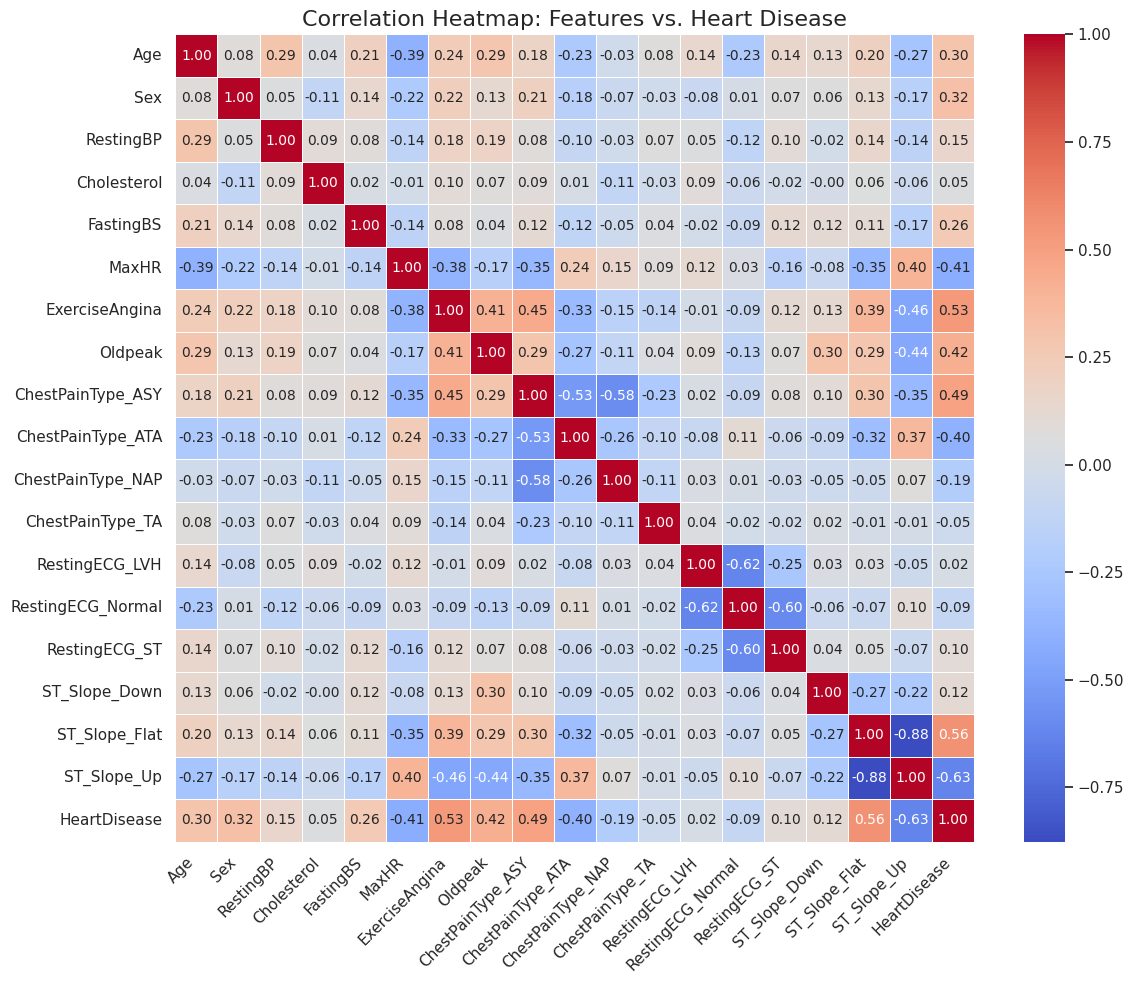

In [236]:
#VISUALIZATION OF ALL THE NUMERIC DATA (INCLUDING THE ENCODED DATA) AND CORRELATION TO HEART DISEASE

#Combine training features and target
#(Ensure X_train contains the new encoded age columns)
train_full = pd.concat([X_train, y_train], axis=1)

#Calculate the correlation matrix
corr_matrix = train_full.corr()

#Create the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,          # Show the numbers in the boxes
            fmt=".2f",           # Round to 2 decimal places
            cmap='coolwarm',     # Red for positive, Blue for negative
            linewidths=0.5,
            annot_kws={"size": 10})

#Adding labels and title
plt.title('Correlation Heatmap: Features vs. Heart Disease', fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.tight_layout()

plt.show()

**Interpretation**: A correlation heatmap was generated  to identify the primary drivers of heart disease within the dataset. The map revealed that Age, Sex, FastingBS,ExerciseAngina, Oldpeak, ChestPainType_ASY and ST_Slope_Flat have the strongest positive correlation of 0.26 to 0.56  with the target variable, while MaxHR, ChestainType_ATA, ChestainType_NAP and ST_Slope_Up showed a significant negative correlation. This showed that physical performance and electrical stability are the most influential factors in predicting cardiovascular risk. Furthermore, the lack of extreme correlation between independent variables ensures that our model is not suffering from redundancy, allowing each feature to provide unique value.

##6. **Exploratory Data Analysis (EDA) and Feature Engineering**

####**Question**: Does heart failure only affect the elderly people more than young people in this dataset?

In [237]:
'''
Age Binning: This step of feature engineering—converting continuous Age into categorical
Age_Category is essential for effective EDA because it allows us to test group-based hypotheses
that raw numbers cannot easily reveal.

'''

def age_binning(age_df):
    # Create the bins based on your hypothesis groups
    # 20-40 (Early), 40-60 (Mid), 60-80 (Senior)
    age_df['Age_Group'] = pd.cut(age_df['Age'],
                             bins=[27, 40, 55, 70, 80],
                             labels=['28-40 (Young)', '41-55 (Middle)', '56-70 (Senior)', '71+ (Elderly)'])

    #Convert these to dummy columns so the model can read them
    age_df = pd.get_dummies(age_df, columns=['Age_Group'], prefix='age', dtype=int)

    return age_df

#Apply to your actual training and testing data
X_train = age_binning(X_train)
X_test = age_binning(X_test)

#This removes any column that has a name we've already seen
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]


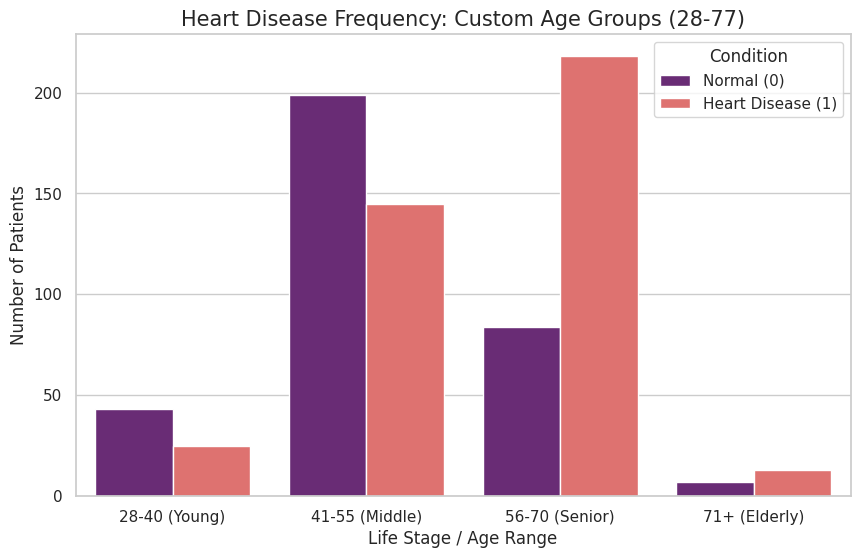

Age_Group
28-40 (Young)     36.764706
41-55 (Middle)    42.151163
56-70 (Senior)    72.185430
71+ (Elderly)     65.000000
Name: HeartDisease, dtype: float64


/tmp/ipykernel_347/3621788423.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(train_data.groupby('Age_Group')['HeartDisease'].mean() * 100)


In [238]:
#Combine training dat
train_data = pd.concat([X_train, y_train], axis=1)

# 3. Create the 'Age_Group' column
train_data['Age_Group'] = pd.cut(train_data['Age'], bins=[27, 40, 55, 70, 80], labels=['28-40 (Young)', '41-55 (Middle)', '56-70 (Senior)', '71+ (Elderly)'])

#Create the Count Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=train_data, x='Age_Group', hue='HeartDisease', palette='magma', legend=False)

#Adding labels and title
plt.title('Heart Disease Frequency: Custom Age Groups (28-77)', fontsize=15)
plt.xlabel('Life Stage / Age Range', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Condition', labels=['Normal (0)', 'Heart Disease (1)'])


plt.show()

#Quick check: See the percentage of heart disease per group
print(train_data.groupby('Age_Group')['HeartDisease'].mean() * 100)

**Interpretation**: The demographic analysis revealed a strong positive correlation between aging and heart disease prevalence. The risk remained relatively stable through early adulthood and middle age (ranging from 36% to 42%) before reaching a critical peak of 72% in the Senior (56-70) segment. Interestingly, the risk actually decreased slightly in the 71+ group (elderly) compared to the 56-70 group (72.19% to 65.00%).This could be due to patients who live past 70 might be healthier overall or have managed their conditions better than those who developed severe issues in their senior segment. This suggests that while heart disease can manifest as early as age 28, the clinical risk more than doubles as patients enter their late 50s, making this a high priority window for preventative screening. This could be due to the Senior age segment is the age range where long term factors like high blood pressure or years of high cholesterol, which culminates in a clinical heart condition.

In [239]:
#Drop the original 'Age' column
X_train = X_train.drop(columns=['Age'])
X_test = X_test.drop(columns=['Age'])

#Check the list again
print("Current columns in Training set:", X_train.columns.tolist())
print("Current columns in Test set:", X_test.columns.tolist())

Current columns in Training set: ['Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up', 'age_28-40 (Young)', 'age_41-55 (Middle)', 'age_56-70 (Senior)', 'age_71+ (Elderly)']
Current columns in Test set: ['Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up', 'age_28-40 (Young)', 'age_41-55 (Middle)', 'age_56-70 (Senior)', 'age_71+ (Elderly)']


####**Question**: In this dataset, which sex (male or female) has a higher frequency of heart disease?

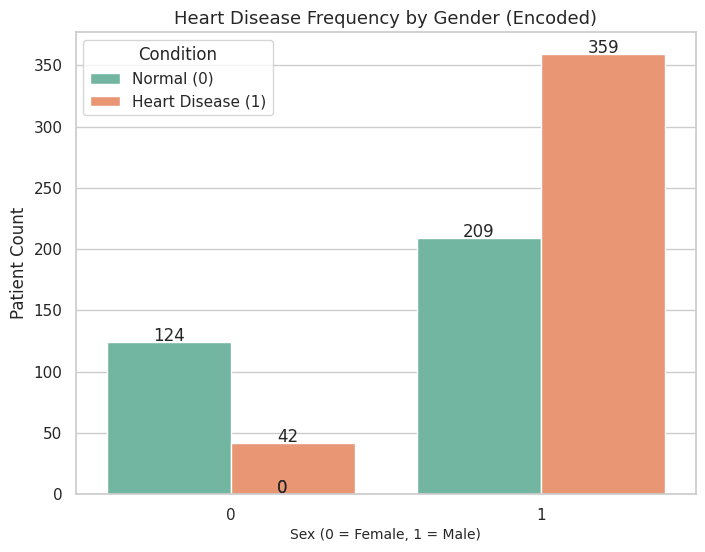

Percentage of Heart Disease by Gender:
HeartDisease          0          1
Sex                               
0             74.698795  25.301205
1             36.795775  63.204225


In [240]:
#Combine training features and target for analysis
train_data = pd.concat([X_train, y_train], axis=1)

#Set the visual style
sns.set_theme(style="whitegrid")

#Create the Count Plot
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=train_data, x='Sex', hue='HeartDisease', palette='Set2')

#Adding labels and title
plt.title('Heart Disease Frequency by Gender (Encoded)', fontsize=13)
plt.xlabel('Sex (0 = Female, 1 = Male)', fontsize=10)
plt.ylabel('Patient Count', fontsize=12)
plt.legend(title='Condition', labels=['Normal (0)', 'Heart Disease (1)'])

#Add value labels on top of the bars for precision
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.15, p.get_height() + 1))

plt.show()

#Statistical Calculation
gender_stats = train_data.groupby('Sex')['HeartDisease'].value_counts(normalize=True).unstack() * 100
print("Percentage of Heart Disease by Gender:")
print(gender_stats)

**Interpretation**: Analysis of the training data revealed a significant sex-based disparity in cardiac pathology. Normalized values (percentages) rather than raw counts were used to ensure the comparison is fair, even if the was more men than women in the dataset.
Patients encoded as Male (1) exhibited a heart disease prevalence of 63.2%, whereas the Female (0) cohort showed a much lower prevalence of 25.3%. This gap suggested that sex is a critical determinant of risk within this dataset. Consequently, the predictive model is expected to weigh the gender feature heavily, identifying the male demographic as a high-priority group for early diagnostic screening.

####**Question**: Which age-sex segment exhibits the highest prevalence of heart disease within the study population?

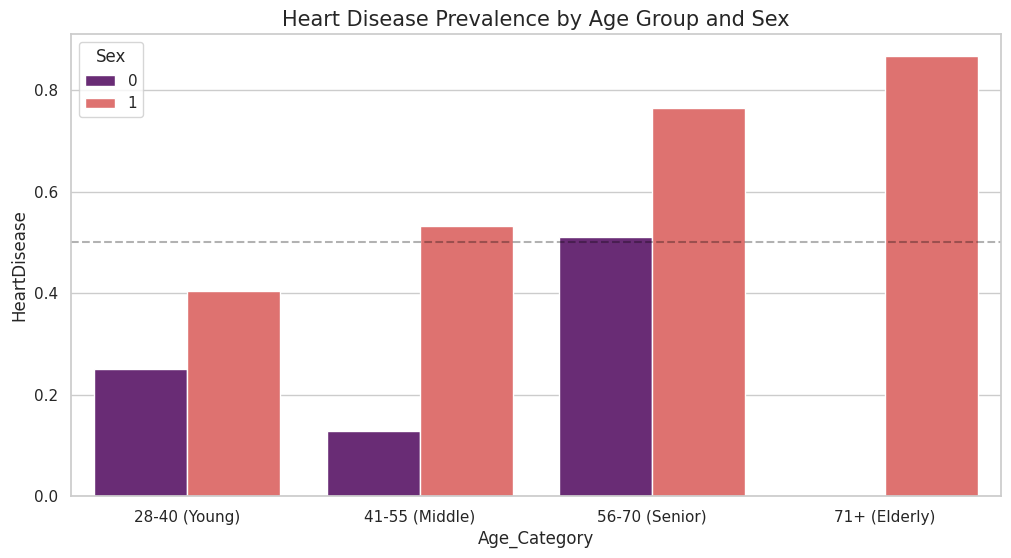

In [241]:

age_dummy_cols = [col for col in train_data.columns if col.startswith('age_')]
train_data['Age_Category'] = train_data[age_dummy_cols].idxmax(axis=1).str.replace('age_', '')

#Get the unique values present in the data to define the order automatically
#This ensures we are using the exact strings present in the column
current_categories = train_data['Age_Category'].unique().tolist()
#Sort them so they are at least somewhat orderly (or define manually if preferred)
current_categories.sort()

plt.figure(figsize=(12, 6))
sns.barplot(data=train_data,
            x='Age_Category',
            y='HeartDisease',
            hue='Sex',
            order=current_categories, # Using the exact names found in the data
            palette='magma',
            errorbar=None)

plt.title('Heart Disease Prevalence by Age Group and Sex', fontsize=15)
plt.axhline(0.5, color='black', linestyle='--', alpha=0.3)

plt.show()

In [242]:
#Check if the training data had the elderly female values
print(train_data[(train_data['Sex'] == 0) & (train_data['Age_Category'] == '71+ (Elderly)')].shape[0])

5


**Interpretation**: The Male (1) bars were significantly taller than the Female (0) bars in every category. Demographic analysis revealed a multifaceted risk profile. While age was a significant driver, with Heart Disease risk peaking in the 56–70 (Senior) cohort—gender acts as an even more consistent predictor. Across all age categories, male patients exhibited a substantially higher prevalence of heart disease. Notably, the risk for males enters a 'critical zone' (exceeding 50% probability) as well as the 41–55 (Middle) age group, whereas female risk levels remained significantly lower until much later in life. This interaction underscores the need for gender-stratified screening protocols in early heart disease detection. As for elderly female group (71+), the training data had five patients in this category, however, the bar for prevalence in this age-gender segment did not appear due to the fact that none of them had heart disease. This was due the the fact that the bar chart above was typically plotting the prevalence of positive cases (HeartDisease=1). Thus every woman aged 71+ was classified Normal(0).

####**Question**: Does having a symptom such as chest pain guarantee a person to be having a heart disease?


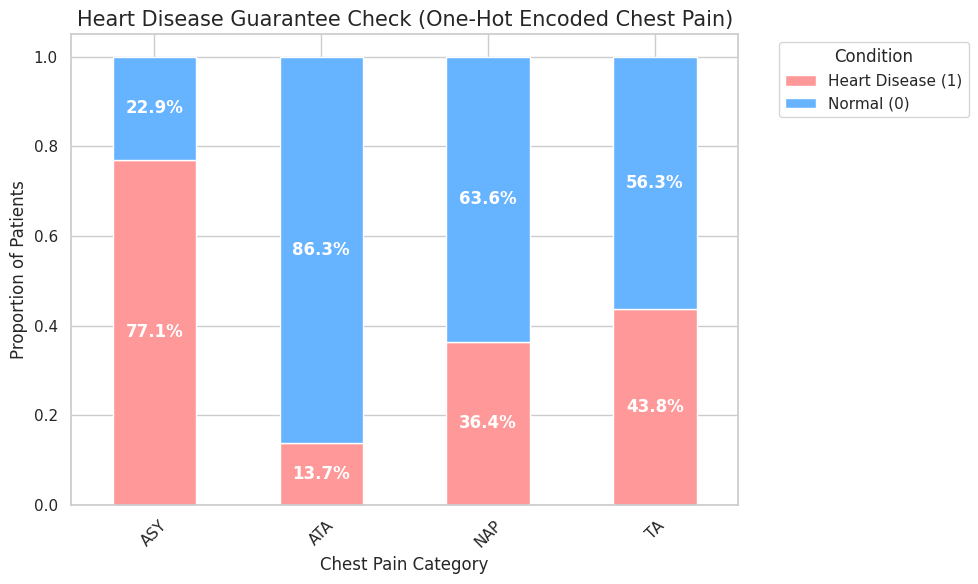

In [243]:
#Identify the dummy columns
# Replace 'ChestPainType_' with the prefix used in one-hot encoding
cp_dummy_cols = [col for col in X_train.columns if 'ChestPainType' in col]

#Calculate prevalence for each dummy category
prevalence_data = []
for col in cp_dummy_cols:
    #Calculate the percentage of HeartDisease (1) when this specific dummy is 1
    #We filter X_train for rows where the dummy is 1, then look at corresponding y_train
    subset_y = y_train[X_train[col] == 1]

    if len(subset_y) > 0:
        disease_pct = subset_y.mean()
        normal_pct = 1 - disease_pct
        prevalence_data.append({
            'Category': col.replace('ChestPainType_', ''),
            'Heart Disease (1)': disease_pct,
            'Normal (0)': normal_pct
        })

#Create a DataFrame for plotting
plot_df = pd.DataFrame(prevalence_data).set_index('Category')

#Plotting the 100% Stacked Bar
ax = plot_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#ff9999', '#66b3ff'])

#Formatting
plt.title('Heart Disease Guarantee Check (One-Hot Encoded Chest Pain)', fontsize=15)
plt.ylabel('Proportion of Patients', fontsize=12)
plt.xlabel('Chest Pain Category', fontsize=12)
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage text
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0.05: # Only label if bar segment is big enough
        x, y = p.get_xy()
        ax.text(x+width/2, y+height/2, f'{height:.1%}',
                ha='center', va='center', color='white', fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Interpretation**: Due to the hypotheical question above, there was no guarantee that having a chest pain is a predictor of having a heart disease. This was seen by the bars of each chest pain type having a split between blue (Normal = 0) and red (HeartDisease = 1). There is no bar with a 100% of either being normal or having a heart disease. Moreover if there was a a 100% guarantee (which is likely impossible), there would have been no need for a model to help predict if a patient is prone to a heart disease.

####**Question**: Which specific categories of Chest Pain Type has the highest prevalence of HeartDisease patients, making it one of the features to use to predict a patient having a heart disease?


Prevalence of Heart Disease by Category:
ChestPainType_ASY    77.057357
ChestPainType_TA     43.750000
ChestPainType_NAP    36.419753
ChestPainType_ATA    13.669065
dtype: float64


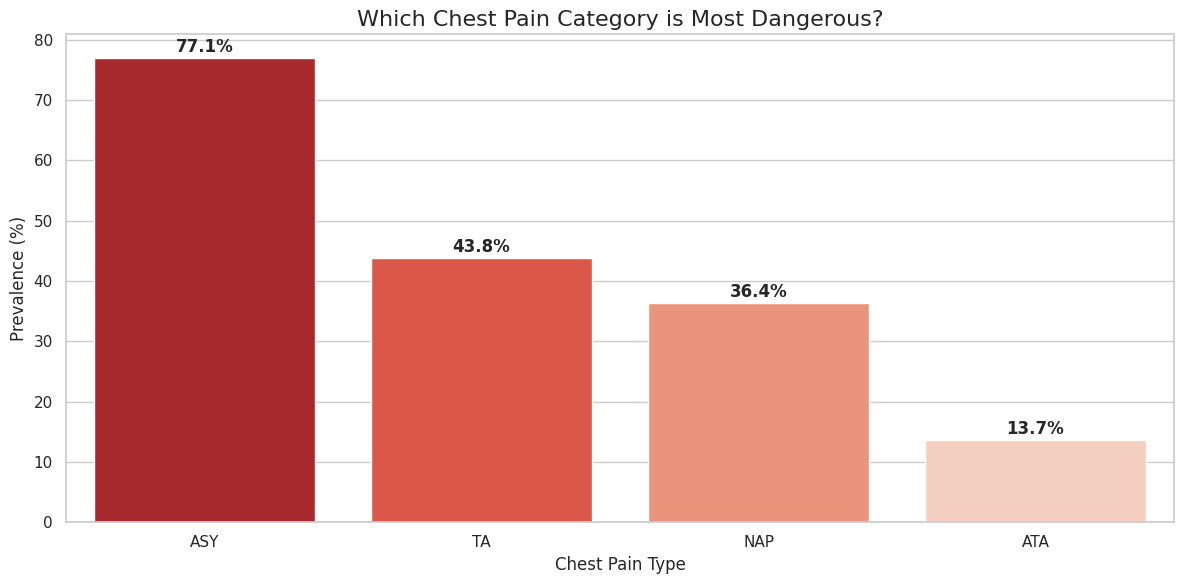

In [244]:
#Identify all the dummy columns for Chest Pain
cp_dummy_cols = [col for col in X_train.columns if col.startswith('ChestPainType_')]

#Calculate the heart disease prevalence for each dummy category
prevalence_dict = {}

for col in cp_dummy_cols:
    # Filter y_train based on where the current dummy column is 1 (True)
    subset_y = y_train[X_train[col] == 1]

    # Calculate the mean (this gives the percentage of 1s)
    if not subset_y.empty:
        prevalence_dict[col] = subset_y.mean() * 100

#Convert to a Series and sort from highest to lowest
cp_prevalence = pd.Series(prevalence_dict).sort_values(ascending=False)

print("Prevalence of Heart Disease by Category:")
print(cp_prevalence)

#Visualization
plt.figure(figsize=(12, 6))
#Remove the prefix from labels for a cleaner chart
clean_labels = [label.replace('ChestPainType_', '') for label in cp_prevalence.index]

sns.barplot(x=clean_labels, y=cp_prevalence.values, hue=clean_labels, palette='Reds_r', legend=False)

#Adding labels and title
plt.title('Which Chest Pain Category is Most Dangerous?', fontsize=16)
plt.ylabel('Prevalence (%)', fontsize=12)
plt.xlabel('Chest Pain Type', fontsize=12)

#Add the exact percentage on top of each bar
for i, v in enumerate(cp_prevalence.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()

plt.show()

**Interpretation**: The graph above was just focussing on the prevalence of patients with a heart disease based of their Chest Pain Types. Asymptomatic (ASY) chest pain has a prevalence of 77.1% making it the chest pain type witht the highest prevalence, making it the most dangerous type for a patient to be diagnosed with a heart disease.  It is a heart attack or "silent ischemia" (reduced blood flow) occurring without the typical, intense chest crushing pain, causing it to go unnoticed. It is the silent but most dangerous category. TA (Typical Angina) is the classic red flag, but it often holds the second highest prevalence, right behind Asymptomatic cases, with a prevalence of 43.8%. It is triggered by physical exertion or emotional stress and is relieved by rest or nitroglycerin, TA is a chest pain that fits the classic description of someone with a heart disease.Even though TA shows the classic symptom of a heart disease, but it is behind ASY because patients with TA often catch the disease early due to their body givng them a warning lights, but with patients with ASY do not give warning lights so by the time the disease is detected, the disease is more advanced, leading to a higher frequency of positive heart disease patients.

Categories like ATA (Atypical Angina) and NAP (Non-Anginal Pain) usually showed much lower prevalence (36.4% and 13.7%). These represent false alarms where the patient feels pain, but it was not related to the heart. Normally it is muscular or digestive pain.
By decomposing the Chest Pain feature into dummy variables, the unique pathological weight of each symptom was isolated. This granular view allows the model to differentiate between critical warning signs and common symptomatic 'noise'.


####**Question**: Is having diabetes (FastingBS 'Blood Sugar') a high risk indicator of having a heart disease?


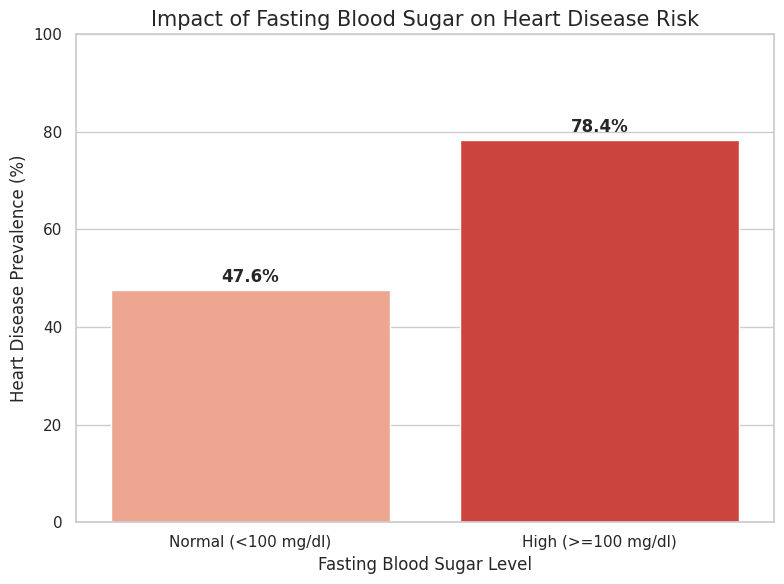

In [245]:
#Calculate the prevalence
sugar_prevalence = train_data.groupby('FastingBS')['HeartDisease'].mean() * 100

#Create the plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=sugar_prevalence.index, y=sugar_prevalence.values, hue=sugar_prevalence.index, palette='Reds', legend=False)

#Add labels and title
plt.title('Impact of Fasting Blood Sugar on Heart Disease Risk', fontsize=15)
plt.xlabel('Fasting Blood Sugar Level', fontsize=12)
plt.ylabel('Heart Disease Prevalence (%)', fontsize=12)

#Improve the X-axis labels for readability
plt.xticks([0, 1], ['Normal (<100 mg/dl)', 'High (>=100 mg/dl)'])

#Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontweight='bold')

plt.ylim(0, 100) # Set Y-axis to 100% to show the full scale
plt.tight_layout()

plt.show()

**Interpretation**: Typically normal fasting blood sugar is below 100mg/dl and a high fasting blood sugar is 100mg/dl and above. The patients with high fasting blood sugar (>= 100mg/dl) had a high heart disease prevalence of 78.4%, while the patients with normal fasting blood sugar (< 100mg/dl) had a heart disease prevalence of 46.6%. FastingBS of >= 10mg/dl (high fasting blood sugar) highlights its role as an indicator of heart disease. This is largely because it damages our blood vessels and nerves and can increase the risk of heart attacks or heart diseases.

####**Question**:How does Resting blood pressure and serum cholesterol affect the likelihood of a heart disease diagnosis?

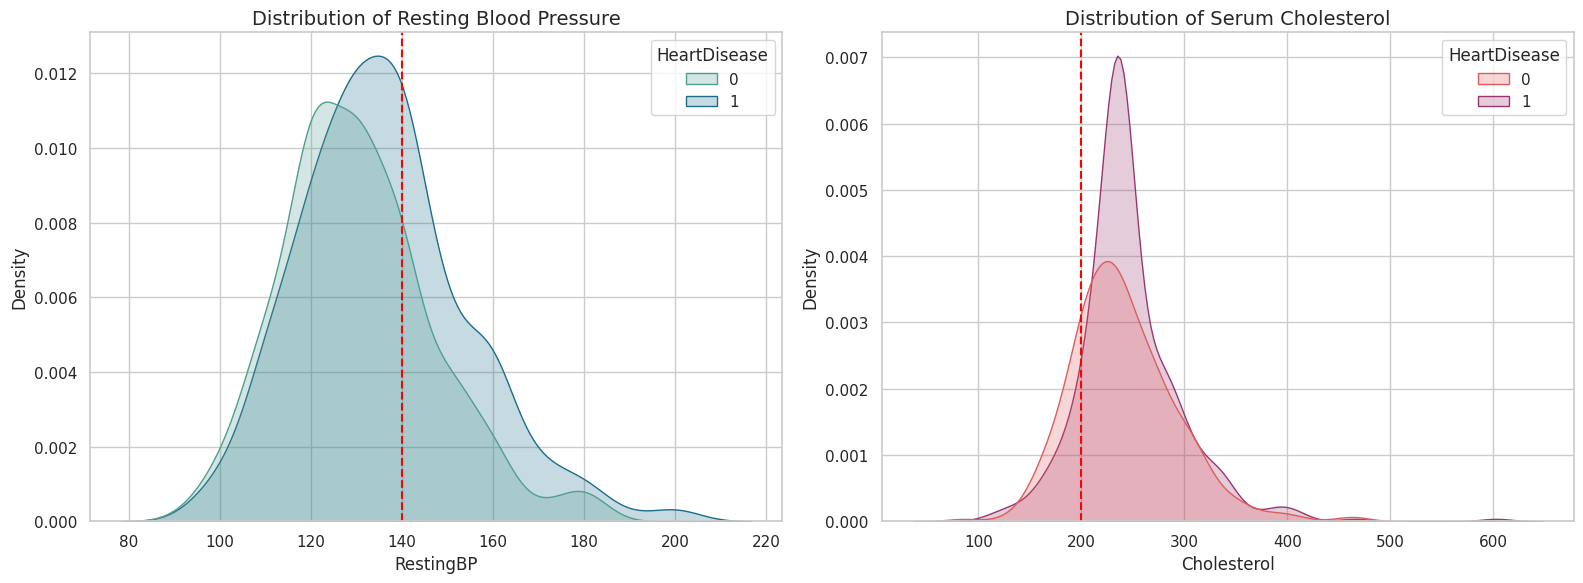

In [246]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Plotting Resting Blood Pressure
sns.kdeplot(ax=axes[0], data=train_data, x='RestingBP', hue='HeartDisease', fill=True, palette='crest')
axes[0].set_title('Distribution of Resting Blood Pressure', fontsize=14)
axes[0].axvline(140, color='red', linestyle='--', label='Hypertension Threshold') # Clinical marker

#Plotting Cholesterol
sns.kdeplot(ax=axes[1], data=train_data, x='Cholesterol', hue='HeartDisease', fill=True, palette='flare')
axes[1].set_title('Distribution of Serum Cholesterol', fontsize=14)
axes[1].axvline(200, color='red', linestyle='--', label='High Cholesterol Threshold') # Clinical marker

plt.tight_layout()

plt.show()

**Interpretation**:The distributional analysis for the RestingBP (blood pressure) revealed that both healthy and diseased cohorts primarily resided to the left of the 140 mmHg (Hypertension) threshold. This suggests that extreme high blood pressure was not the dominant driver of heart disease within this specific population.However, a subtle but critical distinction was found in the probability density: the heart disease curve exhibited a higher concentration within the pre-hypertension range (120–130 mmHg). This indicated that while heart disease patients in this dataset may not be hypertensive, they were more consistently clustered at the higher end of the normal spectrum than their healthy counterparts.
Both cohorts showed significant overlap, with peaks extending beyond the 200 mg/dl clinical threshold. This indicated that elevated cholesterol was prevalent across the entire study population.

While the heart disease cohort showed a notably higher density in the high-cholesterol region confirming it as a consistent marker for heart failure. The substantial overlap with the normal cohort suggested that high cholesterol is a necessary but not sufficient condition. Essentially, while most sick patients had high cholesterol, many healthy patients do as well, reducing its strength as a standalone diagnostic indicator.

The significant overlap observed in both features can be attributed to two primary factors. One being the medication effect.  High risk heart disease patients are often prescribed statins (for cholesterol) or beta-blockers (for BP). These interventions lower clinical numbers, shifting the diseased cohort's data points into normal ranges despite the presence of underlying heart disease.
The second being that RestingBP and Cholesterol are chronic indicators representing long term cardiovascular wear and tear. They describe the patient's environment over years rather than the heart's functional state in the moment.

####**Question**:Which specific EKG ST_Slope shape (Flat, Up, or Down) acts as the strongest mathematical weighted trigger for heart failure when combined with the depth of ST depression (Oldpeak)?

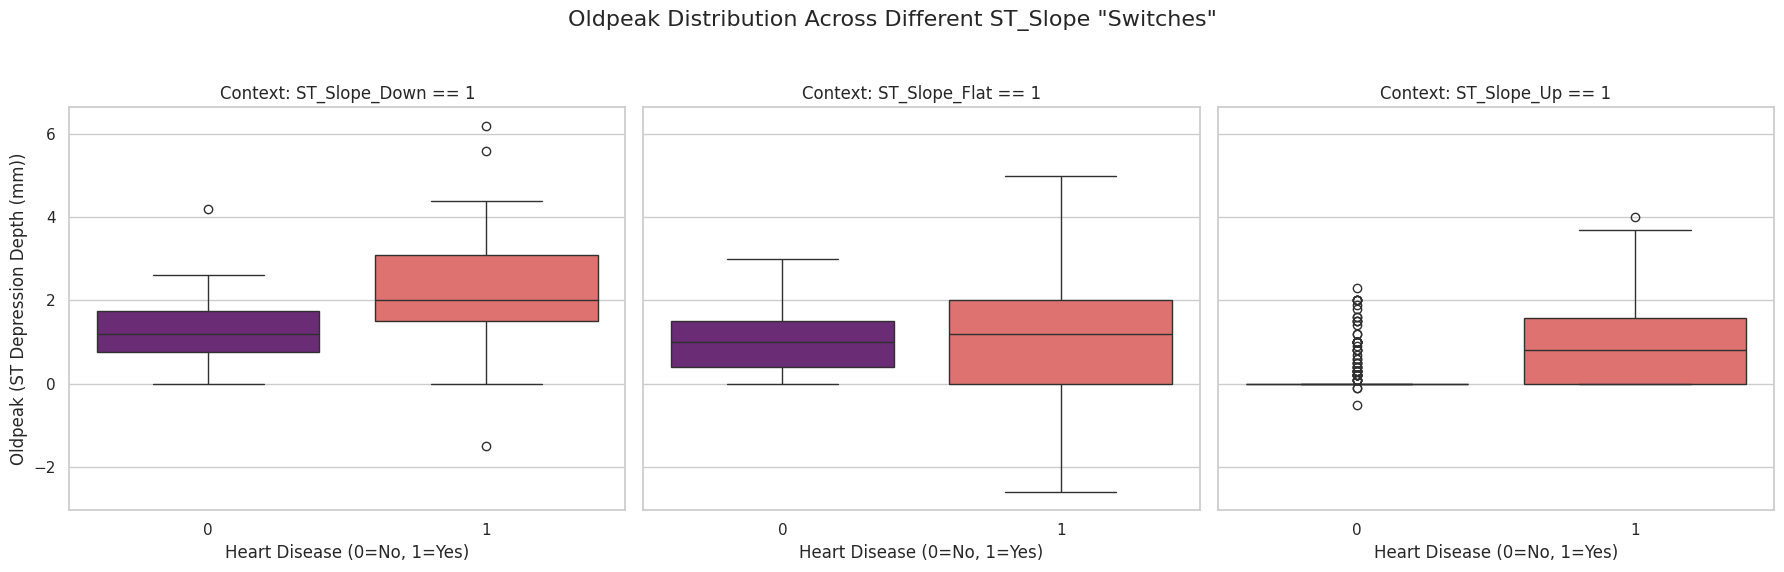

In [247]:
#Identify your dummy columns
slope_dummies = [col for col in train_data.columns if 'ST_Slope' in col]

#Set up the visualization
fig, axes = plt.subplots(1, len(slope_dummies), figsize=(18, 6), sharey=True)

for i, col in enumerate(slope_dummies):
    #Only look at rows where this specific 'switch' is ON (1)
    sns.boxplot(ax=axes[i], data=train_data[train_data[col] == 1],
                x='HeartDisease', y='Oldpeak', hue= 'HeartDisease', palette='magma', legend=False)

    axes[i].set_title(f'Context: {col} == 1', fontsize=12)
    axes[i].set_xlabel('Heart Disease (0=No, 1=Yes)')
    if i == 0:
        axes[i].set_ylabel('Oldpeak (ST Depression Depth (mm))')

plt.suptitle('Oldpeak Distribution Across Different ST_Slope "Switches"', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

**Interpretation**: By visualizing the distribution of Oldpeak (ST depression; a medical measurement used during a heart stress testhow the heart handles physical acticity compared to when you are rested) across the one-hot encoded ST_Slope categories (the shape of how the heart recovers), there was observation of how the intensity of electrical distress varies according to the heart's recovery pattern. When the ST_Slope_Down dummy is active, a clear divergence emerges, healthy patients consistently maintain a low Oldpeak (below 2.0 mm), while those with heart disease shift significantly higher, typically clustering between 1.0 and 3.0 mm. This confirms that a downward slope combined with high ST depression is a strong indicator of cardiovascular distress. In contrast, the ST_Slope_Flat category presents a unique analytical challenge. Both healthy and diseased cohorts are concentrated below the 2.0 mm mark, creating a high overlap zone where Oldpeak alone cannot reliably distinguish between the two groups. This suggests that a flat slope indicates cardiac vulnerability even at low distress levels, requiring tie-breaker features—such as age or chest pain type—to refine the diagnosis. Conversely, the ST_Slope_Up category serves as the model’s negative control, representing the ideal physiological state where most healthy patients exhibit an Oldpeak of exactly 0mm. Interestingly, even in this healthy slope category, there are patients with heart disease. However, their Oldpeak is consistently below 2.0mm. This shows that for some people, heart disease is so subtle that it does not break the Upward recovery pattern of the EKG.

The individual dots observed beyond the boxplot whiskers represent clinically extreme outliers rather than data errors. High value outliers in the heart disease cohort (Oldpeak of 3.0 mm and above) signify individuals with severe arterial blockages who are struggling significantly more than the average patient. Meanwhile, outliers among healthy patients represent false positives caused by non-specific ST changes or unusual heart rhythms that mimic disease on paper. Conversely, heart disease patients with an Oldpeak of 0mm represent cases where the EKG failed to capture the underlying distress. Ultimately, these outliers and overlapping zones underscore the necessity of a multi-feature approach, as no single EKG measurement is sufficient to catch every instance of heart disease.

####**Question**: Does the presence of heart disease consistently lower the Maximum Heart Rate across all age-group dummy variables, and which specific age 'switch' (e.g., age_56-70(Senior)) shows the most dramatic drop in cardiac performance?

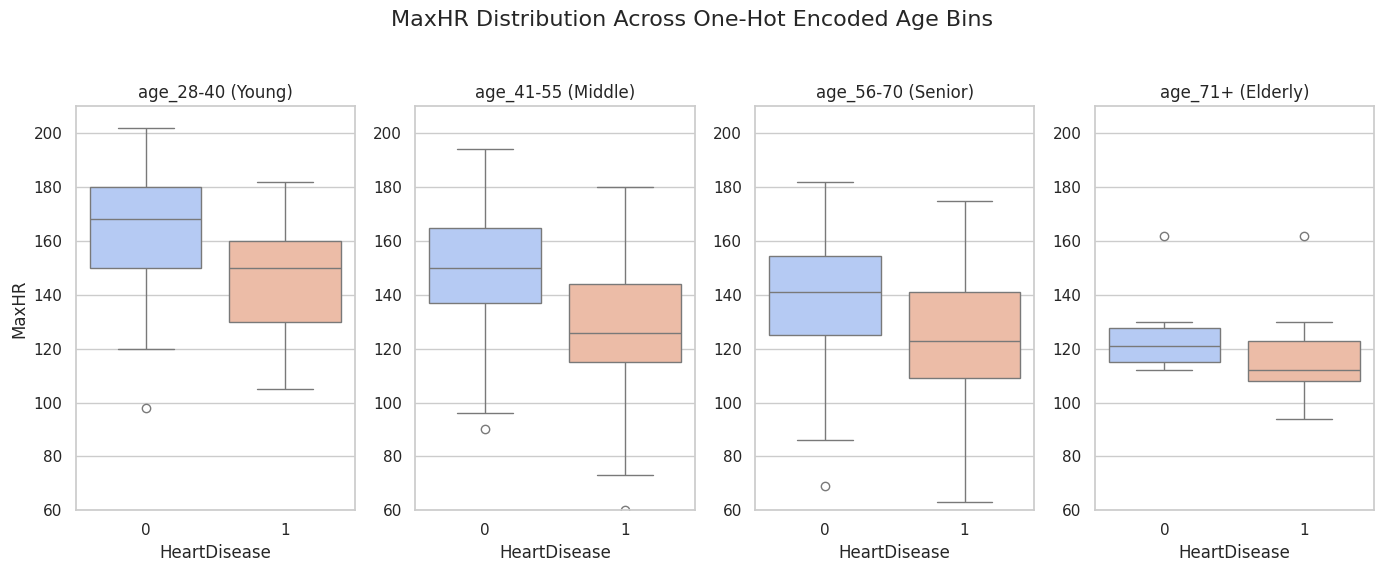

In [248]:
# Identify your age dummy columns
age_dummies = [col for col in train_data.columns if 'age_' in col]

plt.figure(figsize=(14, 6))

# Used a boxplot to see the distribution of MaxHR for each age 'switch'
# The need to iterate through the dummies to see them side-by-side
for i, age_col in enumerate(sorted(age_dummies)):
    plt.subplot(1, len(age_dummies), i+1)
    # Only look at rows where this specific Age Bin is 'ON'
    sns.boxplot(data=train_data[train_data[age_col] == 1],
                x='HeartDisease', y='MaxHR', hue='HeartDisease', palette='coolwarm', legend=False)
    plt.title(f'{age_col}')
    plt.ylim(60, 210) # Keep Y-axis the same for comparison
    if i > 0: plt.ylabel('') # Remove y-label for cleaner look

plt.suptitle('MaxHR Distribution Across One-Hot Encoded Age Bins', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


**Interpretation**: The observed decline in MaxHR across all age bins was consistent with the standard physiological aging process, characterized by the natural pacemaker (SA node) losing some of its sensitivity, decreased beta-adrenergic responsiveness (low adrenaline response), and the natural stiffening of the heart muscle over time makes it physically harder for the heart to beat at very high speeds. However, the critical distinction in this dataset was the relative deficit. While healthy patients followed the expected age-predicted decline, heart disease patients exhibited a significantly lower baseline in every bin. This indicated that heart disease imposes a functional tax on top of natural aging, further limiting the heart's ability to reach its peak capacity during physical exertion. Moreover, analysis revealed that the diagnostic sensitivity of MaxHR was highest in the Young (28–40) cohort, where the gap between healthy and diseased cardiac performance was most dramatic. In younger patients, heart disease causes a massive deviation from the high physiological baseline because it is easy to spot a disease against a high performance baseline. As age increases, this heart rate gap progressively narrows as disease started to overlap with natural aging signals. By the Elderly (71+) stage, natural aging and pathological decline converge, making MaxHR a less distinct marker

####**Question**: Does ExerciseAngina (chest pain during a workout) act like a 'speed limiter' for the MaximumHR (maximun heart rate)? By looking at this plot, can we see a clear 'performance gap' where sick patients are forced to stop at a lower heart rate than healthy people?

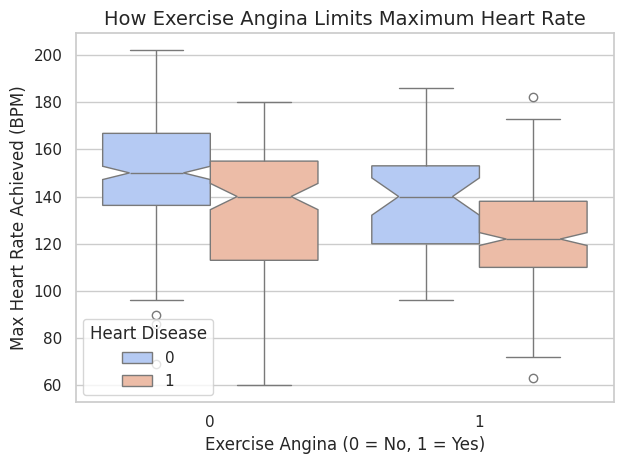

In [249]:
# Setting a professional style
sns.set_theme(style="whitegrid")

#used a boxplot to see how Exercise Angina (0 or 1) lowers the MaxHR baseline.
# The 'notch' helps show the confidence interval around the median.
ax = sns.boxplot(
    data=train_data,
    x='ExerciseAngina',
    y='MaxHR',
    hue='HeartDisease',
    palette='coolwarm',
    notch=True
)

# Adding clear labels and a title for the report
ax.set_title('How Exercise Angina Limits Maximum Heart Rate', fontsize=14)
ax.set_xlabel('Exercise Angina (0 = No, 1 = Yes)')
ax.set_ylabel('Max Heart Rate Achieved (BPM)')
ax.legend(title='Heart Disease', loc='lower left')

plt.tight_layout()

plt.show()


**Interpretation**: This visualization confirmed a powerful interaction between a patient's symptoms and their physical performance. There was a clear downward shift in MaxHR for patients who experience Exercise Angina (the “1” category). This proves that chest pain acts as a physical speed limiter, forcing patients to stop exertion before their heart can reach its full potential. Even within the same category of those without pain, patients with Heart Disease (red boxes) consistently showed a lower MaxHR than healthy patients (blue boxes). This suggests that heart disease reduces efficiency even when symptoms are not immediately present. The lowest heart rates in the entire study were found in the group that had both heart disease and exercise-induced pain. These two features are some of the most reliable predictors for a positive diagnosis.

####**Question**: How do specific RestingECG categories, such as Left Ventricular Hypertrophy (LVH), correlate with a higher probability of heart disease, and do they serve as an early warning sign for the distress we see later in the stress test?


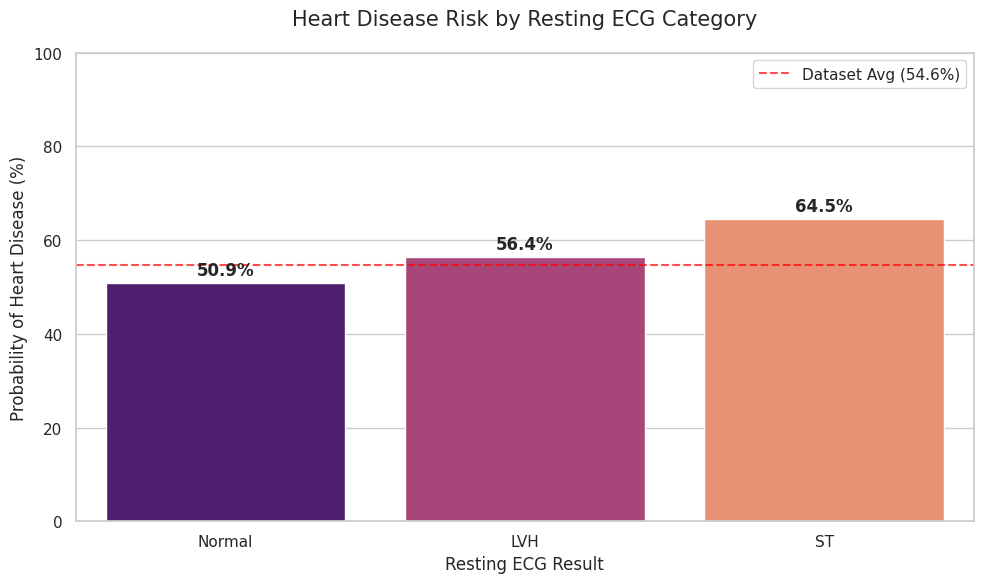

In [250]:
#Prepare the data for plotting
#Ensure these column names matches one-hot encoded column names exactly
ecg_columns = ['RestingECG_Normal', 'RestingECG_LVH', 'RestingECG_ST']
rates = []

for col in ecg_columns:
    # Filter for rows where this specific ECG type is present (== 1)
    if col in train_data.columns:
        subset = train_data[train_data[col] == 1]
        if not subset.empty:
            rate = subset['HeartDisease'].mean() * 100
            rates.append({'ECG_Type': col.replace('RestingECG_', ''), 'HD_Probability': rate})

#Create a summary DataFrame
viz_df = pd.DataFrame(rates)

#Create the Visualization
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

#Create the bar plot
ax = sns.barplot(data=viz_df, x='ECG_Type', y='HD_Probability', hue='ECG_Type',palette='magma', legend=False)

# FIX: Iterate through all containers to ensure every bar gets a label
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=12, fontweight='bold')

#Adding labels and titles
ax.set_title('Heart Disease Risk by Resting ECG Category', fontsize=15, pad=20)
ax.set_xlabel('Resting ECG Result', fontsize=12)
ax.set_ylabel('Probability of Heart Disease (%)', fontsize=12)

#Set the y-axis limit slightly higher to prevent labels from touching the top edge
ax.set_ylim(0, 100)

#Add a horizontal line for the Dataset Average
avg_risk = train_data['HeartDisease'].mean() * 100
plt.axhline(avg_risk, color='red', linestyle='--', alpha=0.7, label=f'Dataset Avg ({avg_risk:.1f}%)')
plt.legend()

plt.tight_layout()

plt.show()

**Interpretation**: The analysis showed a clear "risk ladder" in which a Normal ECG (50.9% Heart Disease risk) was not necessarily a clean bill of health, but rather a neutral starting point that requires more testing to prove safety. Left ventricular hypertrophy (LVH) with a 56.4% Heart Disease prevalence acted as a structural warning, showing the heart muscle had thickened from working too hard for too long. The most serious red flag was ST-T wave abnormality that had a prevalence of 64.5% for Heart Disease, which indicated that the heart was already struggling with electrical issues or poor blood flow even before exercise begins. By identifying these resting patterns, the model gained a head start, allowing it to better predict which patients will likely experience chest pain or heart rate drops during the actual stress test.

###5.2 Feature Scaling

Features like Cholesterol (which can be 200+) and Oldpeak (which might be 0.5) have very different scales. If we don't scale them, the model might "think" Cholesterol is more important simply because the numbers are bigger.Scaling makes them comparable.
Only want to scale our numerical/continuous features. Do not scale the binary (0/1) or one-hot encoded columns, as they are already on a small, fixed scale

In [251]:
from sklearn.preprocessing import StandardScaler

#Target only the continuous columns
numeric_cols = ['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

#Reset the scaler
scaler = StandardScaler()

#Fit and Transform (This overwrites the 'integers' with precise 'floats')
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

#Final verification
print("--- Check the Means Now ---")
print(X_train[numeric_cols].describe().round(4))

--- Check the Means Now ---
       RestingBP  Cholesterol     MaxHR   Oldpeak
count   734.0000     734.0000  734.0000  734.0000
mean      0.0000      -0.0000   -0.0000    0.0000
std       1.0007       1.0007    1.0007    1.0007
min      -2.2096      -3.1436   -3.0096   -3.2388
25%      -0.7456      -0.5721   -0.7182   -0.8363
50%      -0.1825      -0.1369    0.0720   -0.2819
75%       0.3806       0.4961    0.7436    0.5498
max       3.7591       7.1029    2.6004    4.8927


The mean is 0.0 and the std is 1.0 for the scaled data, this shows that data was successfully scaled.



In [252]:
#Print a simple list of all feature names
print("Final Feature List:")
print(list(X_train.columns))

#Check the total number of features
print(f"\nTotal number of features: {len(X_train.columns)}")

#Peek at the top 5 rows to see the data types (Floats vs Integers)
X_train.head()

Final Feature List:
['Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up', 'age_28-40 (Young)', 'age_41-55 (Middle)', 'age_56-70 (Senior)', 'age_71+ (Elderly)']

Total number of features: 21


,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,...,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,age_28-40 (Young),age_41-55 (Middle),age_56-70 (Senior),age_71+ (Elderly)
795,1,-0.745592,-0.077534,1,2.284353,0,-0.097061,False,False,True,...,False,True,False,True,False,False,0,1,0,0
25,1,-0.182505,-0.690742,0,1.652241,0,-0.836286,False,False,True,...,False,True,False,False,False,True,1,0,0,0
84,1,0.943670,-0.611619,1,-0.441628,1,0.087745,True,False,False,...,False,True,False,False,True,False,0,0,1,0
10,0,-0.182505,-0.651181,0,0.229991,0,-0.836286,False,False,True,...,False,True,False,False,False,True,1,0,0,0
344,1,-0.745592,-0.136876,1,-1.271274,0,-0.836286,True,False,False,...,False,True,False,False,True,False,0,1,0,0


##8. Model Development and Evaluation

In [253]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

#Initialize the Model (max_iter ensures the math has enough time to 'converge')
model = LogisticRegression(max_iter=1000)

#Train the model using your preprocessed features
model.fit(X_train, y_train)

#Predict on the unseen test data
y_pred = model.predict(X_test)

# Print the results
print("--- Heart Failure Prediction Performance ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Metrics:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Heart Disease']))

--- Heart Failure Prediction Performance ---
Overall Accuracy: 85.87%

Detailed Metrics:
               precision    recall  f1-score   support

       Normal       0.81      0.87      0.84        77
Heart Disease       0.90      0.85      0.88       107

     accuracy                           0.86       184
    macro avg       0.85      0.86      0.86       184
 weighted avg       0.86      0.86      0.86       184



An accuracy of 86% means that for every 100 patients the model sees, it correctly classifies 86 of them. In the context of heart failure, this is a solid "baseline" that suggests the model has a firm grasp on the dataset's features.

**Heart Disease Analysis**

* Precision (90%): This was the strongest metric, which means there are a few false positives. It predicts that a patient has heart disease 90% of the time correctly.

* Recall(85%): This is the sensitivity. The model successfully identified 85% of all actual heart disease cases.

* F1-Score(88%): This is higher than the Normal groups's F1-Score, it showed that the model was actually better at identifying heart disease than it identified healthy patients.

**Normal Analysis**

* Precision(81%): This was lower than the disease group, which meant that whe the model predicted someone to be normal it was wrong about 19% of the time (they actually had heart disease).

*Recall(87%): The model was very good at clearing healthy or normal people, correctly identifying 87% of the healthy population.

* F1-Score (84%): A solid score but slightly lower than the heart disease group due to the lower precision.

The Macro Average(86%), showed that the Heart Disease and Normal were equally important.Weighted Average (86%), acounts for the number of samples in each class.  This tells us that the dataset was well balanced because the percentages for both matches the accuracy (86%)for the Logistic Regression model.

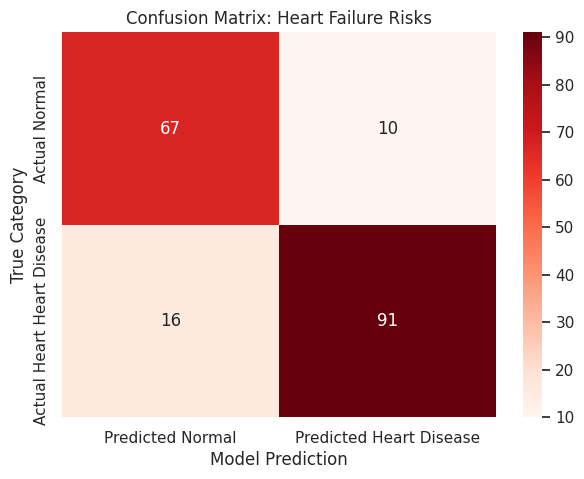

In [254]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Normal', 'Predicted Heart Disease'],
            yticklabels=['Actual Normal', 'Actual Heart Heart Disease'])
plt.title('Confusion Matrix: Heart Failure Risks')
plt.ylabel('True Category')
plt.xlabel('Model Prediction')

plt.savefig('heart_disease_distribution.png')
plt.show()

**Overfitting**

In [255]:
#Get predictions for both sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

#Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2%}")
print(f"Test Accuracy: {test_accuracy:.2%}")

#Check the "Gap"
gap = train_accuracy - test_accuracy
print(f"Performance Gap: {gap:.2%}")

if gap > 0.10:
    print("Warning: Potential Overfitting detected. The model is performing significantly better on seen data.")
else:
    print("The model seems to generalize well to new data.")

Training Accuracy: 87.06%
Test Accuracy: 85.87%
Performance Gap: 1.19%
The model seems to generalize well to new data.


A remarkably stable model for heart failure prediction was achieved, with a performance gap of just 1.19%. This low delta proves that our model was not just memorizing the training data but it was actually learning the real-world indicators of heart disease. The choice of Logistic Regression proved to be the ideal 'sweet spot' for our dataset size, providing both high accuracy and reliable generalization to new patient data.